Load the datasets

In [1]:
import pandas as pd

users = pd.read_csv("../data/raw/users.csv")
flights = pd.read_csv("../data/raw/flights.csv")
hotels = pd.read_csv("../data/raw/hotels.csv")

Basic inspection

In [2]:
users.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [3]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


In [4]:
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [5]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [6]:
hotels.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [7]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


Isnull Check

In [8]:
users.isnull().sum()

code       0
company    0
name       0
gender     0
age        0
dtype: int64

In [9]:
flights.isnull().sum()

travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

In [10]:
hotels.isnull().sum()

travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64

Remove duplicates

In [11]:
users = users.drop_duplicates()

In [12]:
flights = flights.drop_duplicates()

In [13]:
hotels = hotels.drop_duplicates()

Convert date columns

In [14]:
flights["date"] = pd.to_datetime(flights["date"])
hotels["date"] = pd.to_datetime(hotels["date"])

Feature engineering

In [15]:
flights["year"] = flights["date"].dt.year
flights["month"] = flights["date"].dt.month
flights["day"] = flights["date"].dt.day
flights["day_of_week"] = flights["date"].dt.day_name()

In [16]:
hotels["booking_month"] = hotels["date"].dt.month

Merge datasets

In [17]:
flight_user = flights.merge(
    users,
    left_on="userCode",
    right_on="code",
    how="left"
)

hotel_user = hotels.merge(
    users,
    left_on="userCode",
    right_on="code",
    how="left"
)

In [18]:
travel_data = flights.merge(
    hotels,
    on=["travelCode", "userCode"],
    how="inner",
    suffixes=("_flight", "_hotel")
)

In [19]:
hotel_user.rename(columns={'name_x': 'hotel_name', 'name_y': 'name'}, inplace=True)

Save processed datasets

In [20]:
flight_user.to_csv(
    "../data/processed/flight_user.csv",
    index=False
)

hotel_user.to_csv(
    "../data/processed/hotel_user.csv",
    index=False
)

travel_data.to_csv(
    "../data/processed/travel_data.csv",
    index=False
)

<Axes: ylabel='Density'>

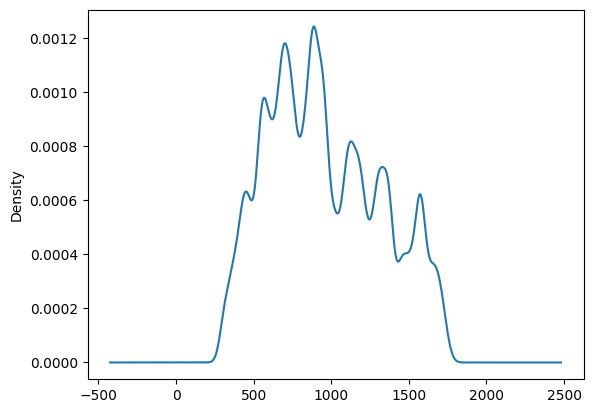

In [21]:
flights["price"].plot(kind='kde')

<Axes: xlabel='hotel_name'>

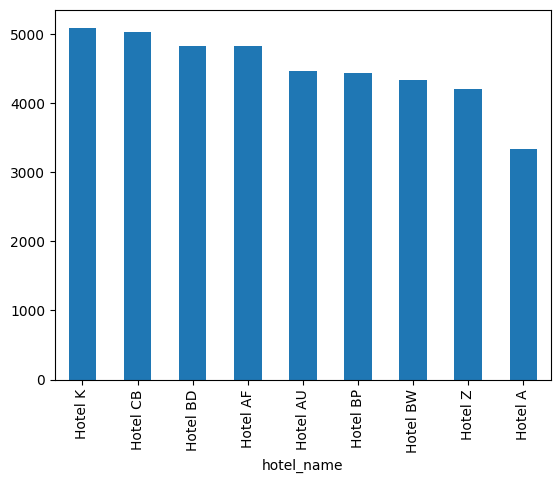

In [22]:
hotel_user["hotel_name"].value_counts().plot(
    kind="bar"
)



<Axes: xlabel='place'>

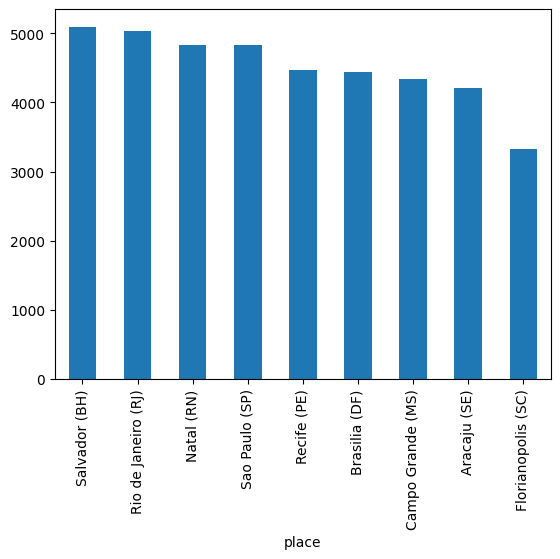

In [23]:
hotel_user["place"].value_counts().plot(
    kind="bar"
)